# 2. Classification with k-fold cross-validation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
DATA_PATH = Path("../data")
FIGURES_PATH = Path("../figures")

## Load train set (the test set is not used in this notebook)

In [2]:
train_data = pd.read_csv(DATA_PATH / "train_processed.csv")

X_train = train_data.drop(columns="y")
y_train = train_data["y"]
X_train.shape

(32940, 14)

## Numerical and categorical features

In [3]:
categorical_features = X_train.select_dtypes(exclude="number").columns.tolist()
numerical_features = X_train.select_dtypes(include="number").columns.tolist()
print("Numerical:", numerical_features)
print("Categorical:", categorical_features)

Numerical: ['age', 'campaign', 'previous', 'cons.price.idx', 'cons.conf.idx', 'nr.employed', 'previously_contacted']
Categorical: ['job', 'marital', 'education', 'default', 'contact', 'month', 'poutcome']


## Preprocessing (fitted inside each fold → no data leakage)
- Numerical: standard scaling
- Categorical: one-hot encoding, categories with < 100 samples grouped as "infrequent"

In [4]:
preprocessor = ColumnTransformer([
    ("numerical", StandardScaler(), numerical_features),
    ("categorical", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                  min_frequency=100,
                                  sparse_output=False), categorical_features),
])

## Classifiers
- `class_weight="balanced"` in SVM and RF to compensate the class imbalance (11% yes)

In [5]:
classifiers = {
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(class_weight="balanced", random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
}

## Metrics
- **ROC-AUC**: evaluates the ranking of clients for every threshold; not affected by the class imbalance
- **F1 (class yes)**: balance between precision and recall of the minority class; accuracy is misleading (88.7% predicting always "no")

In [6]:
SCORING_METRICS = ["roc_auc", "f1"]

## Stratified 5-fold cross-validation (train set only)

In [ ]:
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []
for classifier_name, classifier in classifiers.items():
    classification_pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("classifier", classifier),
    ])
    fold_scores = cross_validate(
        classification_pipeline, X_train, y_train,
        cv=stratified_kfold,
        scoring=SCORING_METRICS,
        return_train_score=True,
        n_jobs=-1,
    )
    for metric in SCORING_METRICS:
        cv_results.append({
            "classifier": classifier_name,
            "metric": metric,
            "train_mean": fold_scores[f"train_{metric}"].mean(),
            "validation_mean": fold_scores[f"test_{metric}"].mean(),
            "validation_std": fold_scores[f"test_{metric}"].std(),
        })
    print(f"{classifier_name}: done")

Naive Bayes: done
SVM: done
KNN: done
Random Forest: done


## Cross-validation results

In [8]:
cv_results = pd.DataFrame(cv_results)
cv_results.round(3)

,classifier,metric,train_mean,validation_mean,validation_std
0,Naive Bayes,roc_auc,0.761,0.759,0.012
1,Naive Bayes,f1,0.399,0.397,0.015
2,SVM,roc_auc,0.851,0.772,0.010
3,SVM,f1,0.487,0.470,0.012
4,KNN,roc_auc,0.924,0.731,0.005
5,KNN,f1,0.503,0.369,0.025
6,Random Forest,roc_auc,0.997,0.742,0.005
7,Random Forest,f1,0.822,0.389,0.009


## Comparison of classifiers (mean ± std over the 5 validation folds)

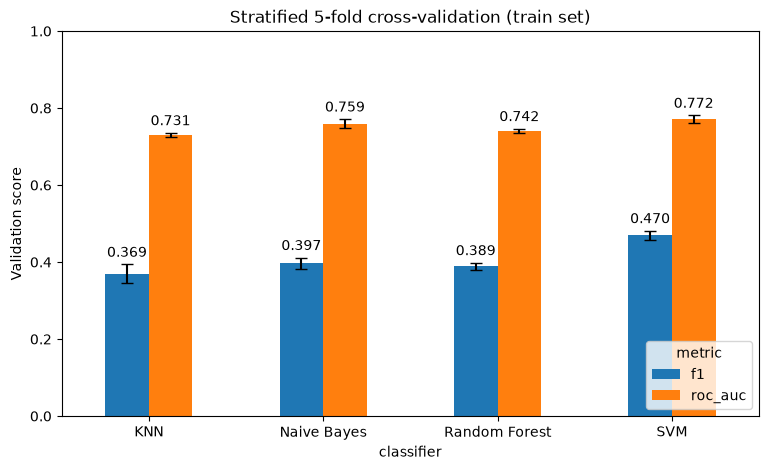

In [9]:
validation_means = cv_results.pivot(index="classifier", columns="metric", values="validation_mean")
validation_stds = cv_results.pivot(index="classifier", columns="metric", values="validation_std")

ax = validation_means.plot(kind="bar", yerr=validation_stds, capsize=4, figsize=(9, 5), rot=0)
for bars in ax.containers:
    if hasattr(bars, "patches"):
        ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_ylim(0, 1)
ax.legend(title="metric", loc="lower right")
ax.set_ylabel("Validation score")
ax.set_title("Stratified 5-fold cross-validation (train set)")
plt.savefig(FIGURES_PATH / "06_cv_classifier_comparison.png", bbox_inches="tight")
plt.show()

## Generalization gap (train − validation)

In [10]:
cv_results["generalization_gap"] = cv_results["train_mean"] - cv_results["validation_mean"]
cv_results.pivot(index="classifier", columns="metric", values="generalization_gap").round(3)

metric,f1,roc_auc
classifier,,
KNN,0.134,0.193
Naive Bayes,0.002,0.002
Random Forest,0.432,0.255
SVM,0.017,0.080
